In [15]:
import numpy as np
import matplotlib.pyplot as plt


In [16]:
data = np.load('data/viola_jones.npz')

In [17]:
X=data['data_matrix']
Y=data['target']

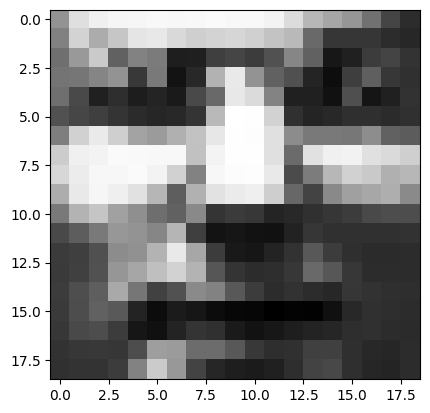

In [18]:
plt.imshow(X[0,:,:], cmap=plt.get_cmap('gray'))

In [19]:
plt.show()

In [20]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [21]:
Xarr= X.reshape(6977, 19*19)
Xtrain, Xvalid, Ytrain, Yvalid = train_test_split(Xarr, Y, test_size =0.2)

In [22]:
#clf = SVC(C=1.0, kernel='linear')
clf = SVC(C=1.0, kernel='linear', probability=True)

In [23]:
clf.fit(Xtrain, Ytrain)

SVC(kernel='linear', probability=True)

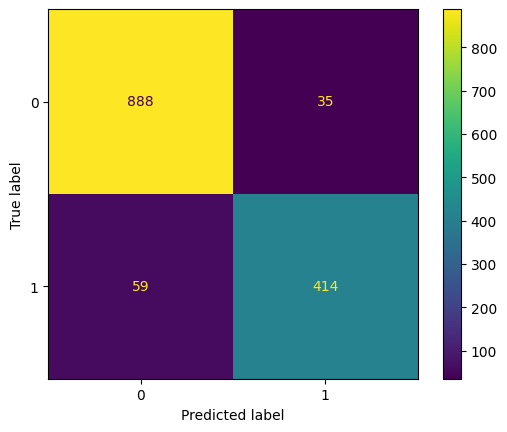

<function matplotlib.pyplot.show(close=None, block=None)>

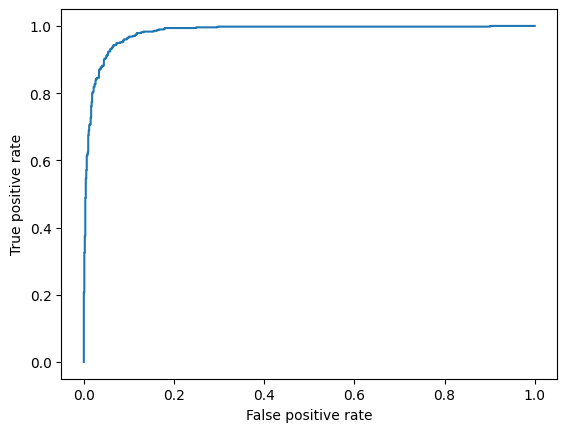

In [24]:
p=clf.predict_proba(Xvalid)

cm=confusion_matrix(Yvalid,  p[:, 1]>0.6)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#fpr, tpr, th = roc_curve(Y, p)
fpr, tpr, th = roc_curve(Yvalid, p[:, 1])
plt.plot(fpr, tpr)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.show